In [22]:
import math
import torch
import torch.nn.functional as F

x = torch.tensor([3.0, 1.0, 4.0, 1.0, 5.0])
reads = 0

# pass 1 — find the max
m = -math.inf
for xi in x:
    reads += 1
    m = max(m, xi.item())

# pass 2 — sum the exponentials, now that we know m
l = 0.0
for xi in x:
    reads += 1
    l += math.exp(xi.item() - m)

# pass 3 — emit
p = []
for xi in x:
    reads += 1
    p.append(math.exp(xi.item() - m) / l)

print(f"m = {m},  l = {l:.4f}")
print("p =", [round(v, 4) for v in p])
print("F =", [round(v, 4) for v in F.softmax(x, dim=-1).tolist()])
print(f"\nreads of x: {reads}  ({reads // len(x)} passes over {len(x)} elements)")


m = 5.0,  l = 1.5398
p = [0.0879, 0.0119, 0.2389, 0.0119, 0.6494]
F = [0.0879, 0.0119, 0.2389, 0.0119, 0.6494]

reads of x: 15  (3 passes over 5 elements)


In [23]:
import torch

x = torch.tensor([3.0, 1.0, 4.0, 1.0, 5.0])

def softmax_with(x, c):
    e = (x - c).exp()
    return e / e.sum()

print("mathematically, c is free:")
for c in [x.max().item(), 0.0, -20.0, 12.5]:
    p = softmax_with(x, c)
    print(f"  c={c:>7.2f}   p = {[round(v, 6) for v in p.tolist()]}")

print("\nnumerically, it is not:")
big = torch.tensor([1000.0, 1001.0, 1002.0])
print(f"  c=max  -> {softmax_with(big, big.max().item()).tolist()}")
print(f"  c=0    -> {softmax_with(big, 0.0).tolist()}")      # inf / inf
print(f"  c=1e5  -> {softmax_with(big, 1e5).tolist()}")      # 0 / 0


mathematically, c is free:
  c=   5.00   p = [0.087889, 0.011894, 0.238907, 0.011894, 0.649416]
  c=   0.00   p = [0.087889, 0.011894, 0.238907, 0.011894, 0.649416]
  c= -20.00   p = [0.087889, 0.011894, 0.238907, 0.011894, 0.649416]
  c=  12.50   p = [0.087889, 0.011894, 0.238907, 0.011894, 0.649416]

numerically, it is not:
  c=max  -> [0.09003057330846786, 0.2447284758090973, 0.6652409434318542]
  c=0    -> [nan, nan, nan]
  c=1e5  -> [nan, nan, nan]


In [24]:
c_old, c_new = 0.0, x.max().item()
e_old = (x - c_old).exp()

alpha = torch.tensor(c_old - c_new).exp()
print("\nrescaled:", (e_old * alpha).tolist())
print("recomputed:", (x - c_new).exp().tolist())



rescaled: [0.1353352814912796, 0.018315637484192848, 0.3678794205188751, 0.018315637484192848, 1.0]
recomputed: [0.1353352814912796, 0.018315639346837997, 0.3678794503211975, 0.018315639346837997, 1.0]


In [25]:
import torch

x = torch.tensor([3.0, 1.0, 4.0, 1.0, 5.0, 9.0, 2.0, 6.0])

def stats(v):
    """the two numbers that summarise v"""
    m = v.max()
    l = (v - m).exp().sum()
    return m, l 

for i in range(1, len(x) + 1):
    m, l = stats(x[:i])
    p = (x[:i] - m).exp() / l                       # rebuilt from (m, l) alone
    ok = torch.allclose(p, torch.softmax(x[:i], dim=-1))
    print(f"n={i}  m={m:4.1f}  l={l:8.4f}   softmax reproduced: {ok}")


n=1  m= 3.0  l=  1.0000   softmax reproduced: True
n=2  m= 3.0  l=  1.1353   softmax reproduced: True
n=3  m= 4.0  l=  1.4177   softmax reproduced: True
n=4  m= 4.0  l=  1.4675   softmax reproduced: True
n=5  m= 5.0  l=  1.5398   softmax reproduced: True
n=6  m= 9.0  l=  1.0282   softmax reproduced: True
n=7  m= 9.0  l=  1.0291   softmax reproduced: True
n=8  m= 9.0  l=  1.0789   softmax reproduced: True


In [26]:
a, b = x[:4], x[4:]
m_a, l_a = stats(a)
m_b, l_b = stats(b)
m_ab, l_ab = stats(x)

print(f"\nchunk A: m={m_a:.1f} l={l_a:.4f}")
print(f"chunk B: m={m_b:.1f} l={l_b:.4f}")
print(f"whole x: m={m_ab:.1f} l={l_ab:.4f}")
print(f"naive l_a + l_b = {(l_a + l_b):.4f}   <- not it")



chunk A: m=4.0 l=1.4675
chunk B: m=9.0 l=1.0690
whole x: m=9.0 l=1.0789
naive l_a + l_b = 2.5365   <- not it


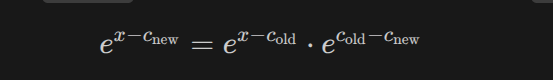

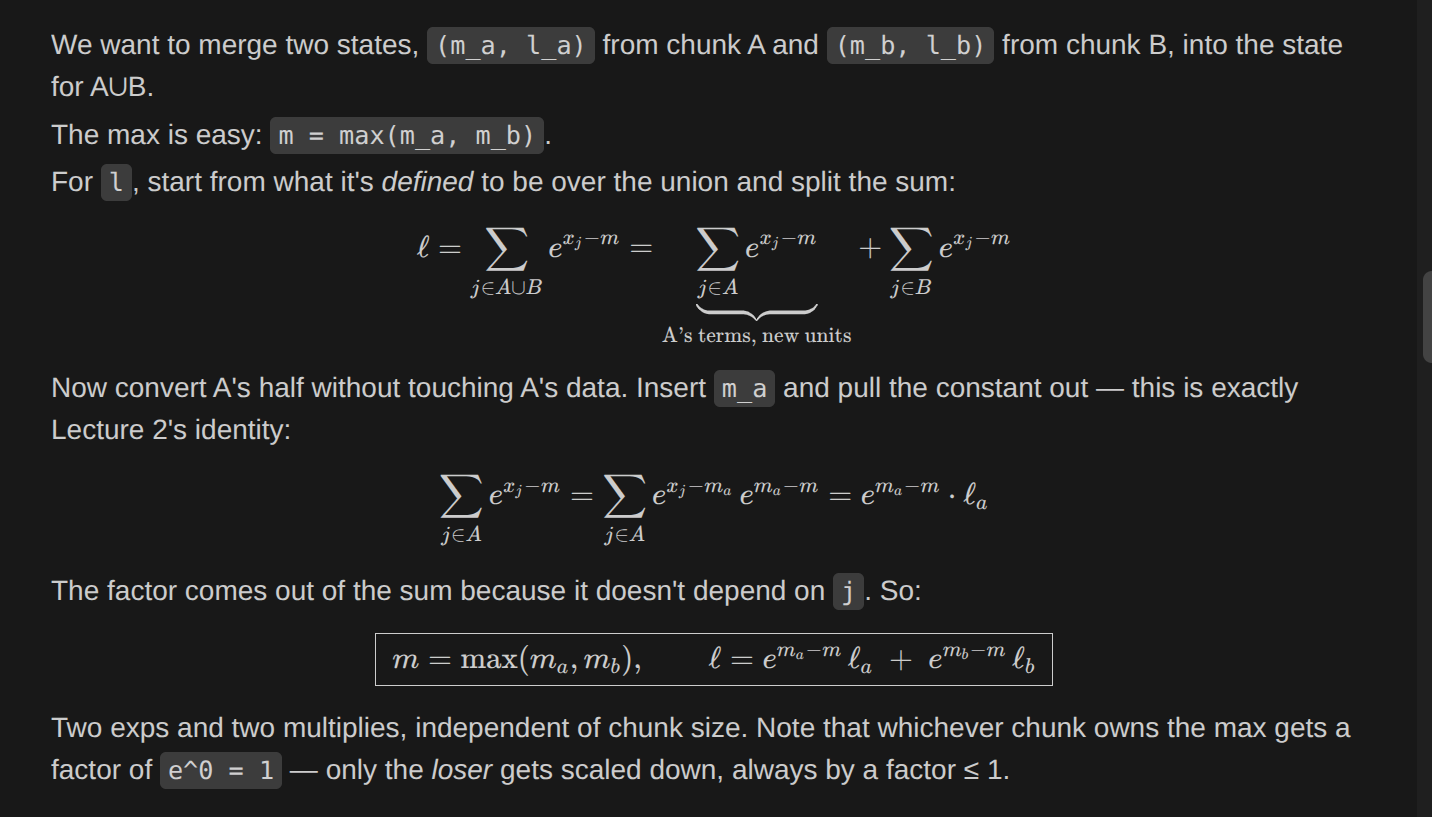

In [29]:
import torch

x = torch.tensor([3.0, 1.0, 4.0, 1.0, 5.0, 9.0, 2.0, 6.0])

def stats(v):
    m = v.max()
    return m, (v - m).exp().sum()

def merge(sa, sb):
    (m_a, l_a), (m_b, l_b) = sa, sb
    m = torch.maximum(m_a, m_b)
    return m, l_a * (m_a - m).exp() + l_b * (m_b - m).exp()

truth = stats(x)
print("truth      ", [round(t.item(), 4) for t in truth])
print("merged A,B ", [round(t.item(), 4) for t in merge(stats(x[:4]), stats(x[4:]))])
print("merged B,A ", [round(t.item(), 4) for t in merge(stats(x[4:]), stats(x[:4]))])


truth       [9.0, 1.0789]
merged A,B  [9.0, 1.0789]
merged B,A  [9.0, 1.0789]


In [30]:
for chunk in (1, 3, 5, 8):
    state = (torch.tensor(-torch.inf), torch.tensor(0.0))
    for c in x.split(chunk):
        state = merge(state, stats(c))          # one pass, O(1) memory
    m, l = state
    p = (x - m).exp() / l
    print(f"chunk={chunk}  m={m:.1f} l={l:.4f}  matches: {torch.allclose(p, torch.softmax(x, -1))}")


chunk=1  m=9.0 l=1.0789  matches: True
chunk=3  m=9.0 l=1.0789  matches: True
chunk=5  m=9.0 l=1.0789  matches: True
chunk=8  m=9.0 l=1.0789  matches: True


In [31]:
import torch

def online_softmax(x, chunk):
    m, l = torch.tensor(-torch.inf), torch.tensor(0.0)
    parts, rescales = [], 0
    for c in x.split(chunk):
        m_new = torch.maximum(m, c.max())
        alpha = (m - m_new).exp()
        e = (c - m_new).exp()
        l = alpha * l + e.sum()
        parts = [p * alpha for p in parts]      # repair every earlier chunk
        rescales += len(parts)
        parts.append(e)
        m = m_new
    return torch.cat(parts) / l, rescales

x = torch.randn(64)
for chunk in (64, 32, 16, 8, 4, 1):
    p, r = online_softmax(x, chunk)
    n = len(x) // chunk
    print(f"chunk={chunk:3d}  n_chunks={n:3d}  rescales={r:5d}  "
          f"n(n-1)/2={n * (n - 1) // 2:5d}  ok={torch.allclose(p, torch.softmax(x, -1))}")


chunk= 64  n_chunks=  1  rescales=    0  n(n-1)/2=    0  ok=True
chunk= 32  n_chunks=  2  rescales=    1  n(n-1)/2=    1  ok=True
chunk= 16  n_chunks=  4  rescales=    6  n(n-1)/2=    6  ok=True
chunk=  8  n_chunks=  8  rescales=   28  n(n-1)/2=   28  ok=True
chunk=  4  n_chunks= 16  rescales=  120  n(n-1)/2=  120  ok=True
chunk=  1  n_chunks= 64  rescales= 2016  n(n-1)/2= 2016  ok=True


In [32]:
import torch
torch.manual_seed(0)

T, hs = 64, 8
q, k, v = torch.randn(hs), torch.randn(T, hs), torch.randn(T, hs)
ref = torch.softmax(q @ k.T / hs**0.5, dim=-1) @ v

def stream_attn(q, k, v, chunk):
    m, l = torch.tensor(-torch.inf), torch.tensor(0.0)
    o = torch.zeros(v.size(-1))
    widest = 0
    for k_c, v_c in zip(k.split(chunk), v.split(chunk)):
        s = q @ k_c.T / q.size(-1) ** 0.5       # only [chunk] scores exist
        widest = max(widest, s.numel())
        m_new = torch.maximum(m, s.max())
        alpha = (m - m_new).exp()
        e = (s - m_new).exp()
        l = alpha * l + e.sum()
        o = alpha * o + e @ v_c                 # ONE rescale, on an [hs] vector
        m = m_new
    return o / l, widest

for chunk in (64, 16, 4, 1):
    out, widest = stream_attn(q, k, v, chunk)
    print(f"chunk={chunk:3d}  scores held={widest:3d}  "
          f"state={2 + hs} floats  err={(out - ref).abs().max():.2e}")


chunk= 64  scores held= 64  state=10 floats  err=8.94e-08
chunk= 16  scores held= 16  state=10 floats  err=8.94e-08
chunk=  4  scores held=  4  state=10 floats  err=5.96e-08
chunk=  1  scores held=  1  state=10 floats  err=8.94e-08


In [33]:
import torch
torch.manual_seed(0)

T, hs = 64, 8
q, k, v = torch.randn(T, hs), torch.randn(T, hs), torch.randn(T, hs)
ref = torch.softmax(q @ k.T / hs**0.5, dim=-1) @ v

def stream_attn(q, k, v, chunk):
    m = q.new_full((q.size(0), 1), -torch.inf)   # [T_q, 1], one max per query
    l = torch.zeros_like(m)                      # [T_q, 1]
    o = torch.zeros_like(q)                      # [T_q, hs]
    widest = 0
    for k_c, v_c in zip(k.split(chunk), v.split(chunk)):
        s = q @ k_c.T / q.size(-1) ** 0.5                    # [T_q, chunk]
        widest = max(widest, s.numel())
        m_new = torch.maximum(m, s.max(-1, keepdim=True).values)
        alpha = (m - m_new).exp()                            # [T_q, 1]
        e = (s - m_new).exp()
        l = alpha * l + e.sum(-1, keepdim=True)
        o = alpha * o + e @ v_c                              # broadcasts over hs
        m = m_new
    return o / l, widest

for chunk in (64, 16, 4):
    out, widest = stream_attn(q, k, v, chunk)
    print(f"chunk={chunk:3d}  scores held={widest:5d}  (full matrix = {T * T})  "
          f"err={(out - ref).abs().max():.2e}")


chunk= 64  scores held= 4096  (full matrix = 4096)  err=2.38e-07
chunk= 16  scores held= 1024  (full matrix = 4096)  err=2.38e-07
chunk=  4  scores held=  256  (full matrix = 4096)  err=2.68e-07
